# Analyze 5v5 Outside Shot Value By Observed Slot Support

This notebook performs a diagnostic aggregate analysis using the labeled chain dataset from Notebook 06.

The purpose is not to prove the obvious claim that “more slot support is better.” The purpose is to test whether the data contains a more useful decision signal, such as:

- whether the largest marginal improvement occurs from `0 → 1` or `1 → 2` observed attackers in the slot,
- whether the `3+` bin plateaus or drops on goal conversion,
- whether observed slot support remains meaningful after filtering out non-offensive-zone outside shots,
- and whether the signal is robust to tracking completeness, defender crowding, and xG tail events.

The analysis cohort is restricted to:

- true 5v5 chains,
- outside-origin shots,
- offensive-zone origin shots at or below the offensive blue line,
- origin tracking available,
- no tracking error flag.

Slot support is measured as **observed identified attacking skaters in the slot**, excluding the shooter and goalies. This is not claimed to be a complete on-ice census.


## 1. Setup

Load libraries, define paths, and configure display options.

In [1]:
# Import libraries used for data analysis and plotting

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Define project paths and notebook-level options

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

DATA_RAW = PROJECT_ROOT / "data" / "raw" / "halo_2026"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "figures"

# Diagnostic plots are shown in the notebook. Saving is off by default to avoid
# committing preliminary artifacts before the final cohort and context filters are set.
SAVE_DIAGNOSTIC_FIGURES = False
EXPORT_REVIEW_ARTIFACTS = False

if SAVE_DIAGNOSTIC_FIGURES:
    FIGURES_DIR.mkdir(exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Raw data exists:", DATA_RAW.exists())
print("Processed data exists:", DATA_PROCESSED.exists())
print("Save diagnostic figures:", SAVE_DIAGNOSTIC_FIGURES)
print("Export review artifacts:", EXPORT_REVIEW_ARTIFACTS)


Project root: c:\Users\rinal\hockey-analytics\outside-shot-value
Raw data exists: True
Processed data exists: True
Save diagnostic figures: False
Export review artifacts: False


In [3]:
# Configure pandas display options for readable notebook tables

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda x: f"{x:0.6f}")

## 2. Load Labeled Chain Dataset

Load the labeled chain dataset created in Notebook 06.

This file should contain one row per origin-shot chain, with strength-state labels and observed tracking slot-support features.

In [4]:
# Load the labeled origin-shot chain dataset

df = pd.read_parquet(DATA_PROCESSED / "origin_shot_sequences_labeled.parquet")

print("df:", df.shape)
df.head()

df: (48673, 75)


,chain_id,game_id,period,sequence_id,team_id,raw_first_chance_team_id,n_team_id_overrides_for_chain,chain_start_time,chain_end_time,chain_duration_seconds,n_chances_in_chain,anchor_origin_event_id,anchor_origin_period_time,anchor_origin_location,anchor_first_chance_event_id,anchor_first_chance_time,anchor_first_event_type,anchor_first_chance_location,first_evaluated_chance_event_id,first_evaluated_chance_time,first_evaluated_event_type,first_evaluated_location,first_evaluated_xg,chain_max_xg,chain_sum_xg,has_deflection,n_deflections,first_deflection_event_id,first_deflection_time,deflection_max_xg,deflection_sum_xg,has_followup_chance,n_followup_chances,first_followup_event_id,first_followup_time,followup_max_xg,followup_sum_xg,chain_goal,chain_goal_event_id,chain_goal_time,chain_goal_player_id,chain_goal_player_name,chain_any_goal_within_2s_flag,origin_tracking_rows,origin_identified_tracking_players,origin_missing_tracking_player_rows,origin_attacker_skaters_tracked,origin_defender_skaters_tracked,observed_origin_attackers_in_slot,observed_origin_defenders_in_slot,origin_goalies_tracked,origin_shooter_tracked,origin_tracking_available,origin_tracking_error_flag,origin_tracking_completeness_bucket,home_team,away_team,home_team_id,away_team_id,team_side,period_time_start,game_stint,period_time_end,n_home_skaters,n_away_skaters,is_home_net_empty,is_away_net_empty,home_score,away_score,origin_time_within_stint,is_5v5,team_n_skaters,opponent_n_skaters,team_net_empty,opponent_net_empty
0,00b0366a-95c6-5250-2dae-e3dd5c4198bc_p1_s11_td...,00b0366a-95c6-5250-2dae-e3dd5c4198bc,1,11,d7ff41e7-8310-f2ab-3c79-6ad3d1f4f019,d7ff41e7-8310-f2ab-3c79-6ad3d1f4f019,0,591.730000,591.730000,0.000000,1,565,591.730000,outside,565,591.730000,shot,outside,565,591.730000,shot,outside,0.040997,0.040997,0.040997,False,0,<NA>,NaN,0.000000,0.000000,False,0,<NA>,NaN,0.000000,0.000000,False,<NA>,NaN,NaN,NaN,False,8,7,1,4,3,1,2,0,True,True,False,partial_observed,GR,CLE,6cac12e2-0546-2c1a-689f-ab26d8a6355a,d7ff41e7-8310-f2ab-3c79-6ad3d1f4f019,away,589.030000,64.000000,605.030000,4.000000,4.000000,False,False,1.000000,1.000000,True,False,4.000000,4.000000,False,False
1,00b0366a-95c6-5250-2dae-e3dd5c4198bc_p1_s12_t6...,00b0366a-95c6-5250-2dae-e3dd5c4198bc,1,12,6cac12e2-0546-2c1a-689f-ab26d8a6355a,6cac12e2-0546-2c1a-689f-ab26d8a6355a,0,722.400000,722.400000,0.000000,1,687,722.400000,outside,687,722.400000,shot,outside,687,722.400000,shot,outside,0.015540,0.015540,0.015540,False,0,<NA>,NaN,0.000000,0.000000,False,0,<NA>,NaN,0.000000,0.000000,False,<NA>,NaN,NaN,NaN,False,10,7,3,4,3,1,2,0,True,True,False,partial_observed,GR,CLE,6cac12e2-0546-2c1a-689f-ab26d8a6355a,d7ff41e7-8310-f2ab-3c79-6ad3d1f4f019,home,719.030000,80.000000,725.030000,5.000000,5.000000,False,False,1.000000,1.000000,True,True,5.000000,5.000000,False,False
2,00b0366a-95c6-5250-2dae-e3dd5c4198bc_p1_s12_t6...,00b0366a-95c6-5250-2dae-e3dd5c4198bc,1,12,6cac12e2-0546-2c1a-689f-ab26d8a6355a,6cac12e2-0546-2c1a-689f-ab26d8a6355a,0,736.330000,736.330000,0.000000,1,702,736.330000,slot,702,736.330000,shot,slot,702,736.330000,shot,slot,0.010975,0.010975,0.010975,False,0,<NA>,NaN,0.000000,0.000000,False,0,<NA>,NaN,0.000000,0.000000,False,<NA>,NaN,NaN,NaN,False,8,5,3,3,2,0,1,0,True,True,False,partial_observed,GR,CLE,6cac12e2-0546-2c1a-689f-ab26d8a6355a,d7ff41e7-8310-f2ab-3c79-6ad3d1f4f019,home,734.030000,83.000000,738.030000,5.000000,5.000000,False,False,1.000000,1.000000,True,True,5.000000,5.000000,False,False
3,00b0366a-95c6-5250-2dae-e3dd5c4198bc_p1_s12_t6...,00b0366a-95c6-5250-2dae-e3dd5c4198bc,1,12,6cac12e2-0546-2c1a-689f-ab26d8a6355a,6cac12e2-0546-2c1a-689f-ab26d8a6355a,0,765.730000,765.730000,0.000000,1,730,765.730000,slot,730,765.730000,shot,slot,730,765.730000,shot,slot,0.089858,0.089858,0.089858,False,0,<NA>,NaN,0.000000,0.000000,False,0,<NA>,NaN,0.000000,0.000000,False,<NA>,NaN,NaN,NaN,False,8,4,4,1,3,1,3,1,False,True,False,partial_observed,GR,CLE,6cac12e2-0546-2c1a-689f-ab26d8a6355a,d7ff41e7-8310-f2ab

In [5]:
# Inspect the available columns before defining analysis cohorts

df.columns.tolist()

['chain_id',
 'game_id',
 'period',
 'sequence_id',
 'team_id',
 'raw_first_chance_team_id',
 'n_team_id_overrides_for_chain',
 'chain_start_time',
 'chain_end_time',
 'chain_duration_seconds',
 'n_chances_in_chain',
 'anchor_origin_event_id',
 'anchor_origin_period_time',
 'anchor_origin_location',
 'anchor_first_chance_event_id',
 'anchor_first_chance_time',
 'anchor_first_event_type',
 'anchor_first_chance_location',
 'first_evaluated_chance_event_id',
 'first_evaluated_chance_time',
 'first_evaluated_event_type',
 'first_evaluated_location',
 'first_evaluated_xg',
 'chain_max_xg',
 'chain_sum_xg',
 'has_deflection',
 'n_deflections',
 'first_deflection_event_id',
 'first_deflection_time',
 'deflection_max_xg',
 'deflection_sum_xg',
 'has_followup_chance',
 'n_followup_chances',
 'first_followup_event_id',
 'first_followup_time',
 'followup_max_xg',
 'followup_sum_xg',
 'chain_goal',
 'chain_goal_event_id',
 'chain_goal_time',
 'chain_goal_player_id',
 'chain_goal_player_name',
 'ch

### Attach Origin Coordinates

The labeled chain dataset intentionally carries chain and tracking features, but it does not include the original shot coordinates.

For this analysis, attach the origin event coordinates from the raw event table so we can exclude outside shots taken from behind the offensive blue line. With offensive-adjusted coordinates, the offensive blue line is approximately `x_adj = 25`. The core cohort should be offensive-zone outside shots, not neutral-zone dump-ins or desperation attempts.


In [6]:
# Attach offensive-adjusted origin coordinates from the raw event table

origin_coord_columns = [
    "game_id",
    "sl_event_id",
    "x_adj",
    "y_adj",
]

events_for_origin_coords = pd.read_parquet(
    DATA_RAW / "events.parquet",
    columns=origin_coord_columns,
)

origin_coords = (
    events_for_origin_coords
    .rename(
        columns={
            "sl_event_id": "anchor_origin_event_id",
            "x_adj": "anchor_origin_x_adj",
            "y_adj": "anchor_origin_y_adj",
        }
    )
    .drop_duplicates(["game_id", "anchor_origin_event_id"])
)

rows_before_coord_join = len(df)

df = df.merge(
    origin_coords,
    on=["game_id", "anchor_origin_event_id"],
    how="left",
    validate="many_to_one",
)

coord_join_validation = {
    "rows_before": rows_before_coord_join,
    "rows_after": len(df),
    "duplicate_chain_ids": df.duplicated("chain_id").sum(),
    "missing_anchor_origin_x_adj": df["anchor_origin_x_adj"].isna().sum(),
    "missing_anchor_origin_y_adj": df["anchor_origin_y_adj"].isna().sum(),
}

coord_join_validation


{'rows_before': 48673,
 'rows_after': 48673,
 'duplicate_chain_ids': np.int64(0),
 'missing_anchor_origin_x_adj': np.int64(2),
 'missing_anchor_origin_y_adj': np.int64(2)}

## 3. Validate Required Columns

Before analysis, confirm that all required fields are present.

This prevents a common failure mode: accidentally analyzing an older parquet file or stale notebook output.

In [7]:
# Check that all fields required for the preliminary analysis are present

required_columns = [
    "chain_id",
    "game_id",
    "period",
    "sequence_id",
    "team_id",
    "is_5v5",
    "anchor_origin_location",
    "first_evaluated_xg",
    "chain_max_xg",
    "followup_max_xg",
    "has_followup_chance",
    "has_deflection",
    "chain_goal",
    "origin_tracking_available",
    "origin_tracking_error_flag",
    "origin_tracking_completeness_bucket",
    "observed_origin_attackers_in_slot",
    "observed_origin_defenders_in_slot",
    "origin_attacker_skaters_tracked",
    "origin_defender_skaters_tracked",
    "anchor_origin_x_adj",
    "anchor_origin_y_adj",
]

missing_required_columns = [c for c in required_columns if c not in df.columns]

missing_required_columns

[]

In [8]:
# Validate one-row-per-chain structure and core label availability

initial_validation = {
    "rows": len(df),
    "unique_chain_ids": df["chain_id"].nunique(),
    "duplicate_chain_ids": df.duplicated("chain_id").sum(),
    "missing_is_5v5": df["is_5v5"].isna().sum(),
    "missing_origin_location": df["anchor_origin_location"].isna().sum(),
    "missing_chain_max_xg": df["chain_max_xg"].isna().sum(),
    "tracking_available_counts": df["origin_tracking_available"].value_counts(dropna=False).to_dict(),
    "tracking_error_flag_counts": df["origin_tracking_error_flag"].value_counts(dropna=False).to_dict(),
}

initial_validation

{'rows': 48673,
 'unique_chain_ids': 48673,
 'duplicate_chain_ids': np.int64(0),
 'missing_is_5v5': np.int64(0),
 'missing_origin_location': np.int64(2),
 'missing_chain_max_xg': np.int64(0),
 'tracking_available_counts': {True: 45343, False: 3330},
 'tracking_error_flag_counts': {False: 48650, True: 23}}

## 4. Define Preliminary Analysis Cohort

The preliminary analysis cohort is:

- 5v5,
- outside-origin,
- offensive-zone origin at or below the offensive blue line,
- origin tracking available,
- no tracking error flag.

The blue-line filter removes neutral-zone or behind-the-blue-line shots that are not the same coaching decision as an offensive-zone outside shot taken to create traffic, deflections, or rebounds.


In [9]:
# Create readable boolean masks for the preliminary outside-shot analysis cohort

OFFENSIVE_BLUE_LINE_X_ADJ = 25

is_5v5 = df["is_5v5"]
is_outside_origin = df["anchor_origin_location"].eq("outside")
is_offensive_zone_origin = df["anchor_origin_x_adj"].ge(OFFENSIVE_BLUE_LINE_X_ADJ)
has_tracking_available = df["origin_tracking_available"]
has_no_tracking_error = ~df["origin_tracking_error_flag"]

analysis_mask = (
    is_5v5
    & is_outside_origin
    & is_offensive_zone_origin
    & has_tracking_available
    & has_no_tracking_error
)

analysis = df[analysis_mask].copy()

analysis_validation = {
    "analysis_rows": len(analysis),
    "min_anchor_origin_x_adj": analysis["anchor_origin_x_adj"].min(),
    "max_anchor_origin_x_adj": analysis["anchor_origin_x_adj"].max(),
    "behind_blue_line_rows_in_analysis": int((analysis["anchor_origin_x_adj"] < OFFENSIVE_BLUE_LINE_X_ADJ).sum()),
}

analysis_validation


{'analysis_rows': 21536,
 'min_anchor_origin_x_adj': np.float64(25.344994),
 'max_anchor_origin_x_adj': np.float64(96.76528),
 'behind_blue_line_rows_in_analysis': 0}

In [10]:
# Build the denominator waterfall for the preliminary analysis cohort

cohort_waterfall = pd.DataFrame(
    [
        {
            "cohort": "all_origin_shot_chains",
            "chains": len(df),
        },
        {
            "cohort": "is_5v5",
            "chains": int(is_5v5.sum()),
        },
        {
            "cohort": "is_5v5_outside_origin",
            "chains": int((is_5v5 & is_outside_origin).sum()),
        },
        {
            "cohort": "is_5v5_outside_origin_offensive_zone",
            "chains": int((is_5v5 & is_outside_origin & is_offensive_zone_origin).sum()),
        },
        {
            "cohort": "is_5v5_outside_origin_offensive_zone_tracking_available",
            "chains": int((is_5v5 & is_outside_origin & is_offensive_zone_origin & has_tracking_available).sum()),
        },
        {
            "cohort": "is_5v5_outside_origin_offensive_zone_tracking_available_no_error_flag",
            "chains": int(analysis_mask.sum()),
        },
    ]
)

cohort_waterfall["pct_of_all"] = cohort_waterfall["chains"] / len(df)
cohort_waterfall["pct_of_previous"] = cohort_waterfall["chains"] / cohort_waterfall["chains"].shift(1)
cohort_waterfall.loc[0, "pct_of_previous"] = 1.0

cohort_waterfall


,cohort,chains,pct_of_all,pct_of_previous
0,all_origin_shot_chains,48673,1.000000,1.000000
1,is_5v5,36357,0.746964,0.746964
2,is_5v5_outside_origin,23754,0.488032,0.653354
3,is_5v5_outside_origin_offensive_zone,22919,0.470877,0.964848
4,is_5v5_outside_origin_offensive_zone_tracking_...,21549,0.442730,0.940224
5,is_5v5_outside_origin_offensive_zone_tracking_...,21536,0.442463,0.999397


## 5. Create Observed Slot-Support Bins

Observed attacking slot support is capped into four bins:

- `0`
- `1`
- `2`
- `3+`

The `3+` bin is capped because higher counts are rare and because observed tracking is not a full on-ice census.

In [11]:
# Convert observed attacking and defending slot counts into capped categorical bins

def cap_slot_count(value):
    if pd.isna(value):
        return pd.NA

    value = int(value)

    if value >= 3:
        return "3+"

    return str(value)


analysis["observed_attackers_slot_bin"] = analysis["observed_origin_attackers_in_slot"].apply(cap_slot_count)
analysis["observed_defenders_slot_bin"] = analysis["observed_origin_defenders_in_slot"].apply(cap_slot_count)

slot_bin_order = ["0", "1", "2", "3+"]

analysis["observed_attackers_slot_bin"] = pd.Categorical(
    analysis["observed_attackers_slot_bin"],
    categories=slot_bin_order,
    ordered=True,
)

analysis["observed_defenders_slot_bin"] = pd.Categorical(
    analysis["observed_defenders_slot_bin"],
    categories=slot_bin_order,
    ordered=True,
)

analysis[
    [
        "observed_origin_attackers_in_slot",
        "observed_attackers_slot_bin",
        "observed_origin_defenders_in_slot",
        "observed_defenders_slot_bin",
    ]
].head()

,observed_origin_attackers_in_slot,observed_attackers_slot_bin,observed_origin_defenders_in_slot,observed_defenders_slot_bin
1,1,1,2,2
4,0,0,1,1
8,2,2,1,1
10,1,1,2,2
13,1,1,2,2


In [12]:
# Check sample sizes by observed attacking slot-support bin

slot_bin_counts = (
    analysis["observed_attackers_slot_bin"]
    .value_counts(dropna=False)
    .sort_index()
)

slot_bin_counts

observed_attackers_slot_bin
0     8280
1     8202
2     4427
3+     627
Name: count, dtype: int64

## 6. Preliminary Summary By Observed Attacking Slot Support

This is the first main table.

Important interpretation rule:

- `mean_chain_max_xg` captures average created value but is sensitive to rare high-xG events.
- `median_chain_max_xg` is more stable for fat-tailed chance distributions.
- follow-up, deflection, and goal rates describe secondary-value creation.

In [13]:
# Summarize outside-origin 5v5 chains by observed attacking slot support

summary_by_attack_support = (
    analysis
    .groupby("observed_attackers_slot_bin", observed=False)
    .agg(
        chains=("chain_id", "count"),
        mean_first_xg=("first_evaluated_xg", "mean"),
        median_first_xg=("first_evaluated_xg", "median"),
        mean_chain_max_xg=("chain_max_xg", "mean"),
        median_chain_max_xg=("chain_max_xg", "median"),
        p75_chain_max_xg=("chain_max_xg", lambda s: s.quantile(0.75)),
        p90_chain_max_xg=("chain_max_xg", lambda s: s.quantile(0.90)),
        mean_followup_max_xg=("followup_max_xg", "mean"),
        followup_rate=("has_followup_chance", "mean"),
        deflection_rate=("has_deflection", "mean"),
        goal_rate=("chain_goal", "mean"),
        mean_observed_defenders_in_slot=("observed_origin_defenders_in_slot", "mean"),
        mean_attacker_skaters_tracked=("origin_attacker_skaters_tracked", "mean"),
        mean_defender_skaters_tracked=("origin_defender_skaters_tracked", "mean"),
    )
    .reset_index()
)

summary_by_attack_support

,observed_attackers_slot_bin,chains,mean_first_xg,median_first_xg,mean_chain_max_xg,median_chain_max_xg,p75_chain_max_xg,p90_chain_max_xg,mean_followup_max_xg,followup_rate,deflection_rate,goal_rate,mean_observed_defenders_in_slot,mean_attacker_skaters_tracked,mean_defender_skaters_tracked
0,0,8280,0.012608,0.004437,0.018228,0.004958,0.013312,0.039763,0.006512,0.087802,0.037560,0.019203,1.305676,2.120652,3.228865
1,1,8202,0.017774,0.005041,0.025088,0.005752,0.017855,0.069089,0.008838,0.099488,0.065106,0.025969,2.014996,2.998171,3.463545
2,2,4427,0.020298,0.005266,0.030378,0.006177,0.024606,0.086784,0.011708,0.109103,0.074091,0.033205,2.346284,3.774565,3.587757
3,3+,627,0.022127,0.005378,0.032636,0.006265,0.024721,0.102332,0.012817,0.106858,0.086124,0.028708,2.620415,4.371611,3.594896


In [14]:
# Add lift metrics relative to the zero-support baseline

baseline_row = summary_by_attack_support[
    summary_by_attack_support["observed_attackers_slot_bin"].astype(str).eq("0")
].iloc[0]

summary_by_attack_support["median_chain_max_xg_lift_vs_0"] = (
    summary_by_attack_support["median_chain_max_xg"]
    - baseline_row["median_chain_max_xg"]
)

summary_by_attack_support["mean_chain_max_xg_lift_vs_0"] = (
    summary_by_attack_support["mean_chain_max_xg"]
    - baseline_row["mean_chain_max_xg"]
)

summary_by_attack_support["followup_rate_lift_vs_0"] = (
    summary_by_attack_support["followup_rate"]
    - baseline_row["followup_rate"]
)

summary_by_attack_support["deflection_rate_lift_vs_0"] = (
    summary_by_attack_support["deflection_rate"]
    - baseline_row["deflection_rate"]
)

summary_by_attack_support["goal_rate_lift_vs_0"] = (
    summary_by_attack_support["goal_rate"]
    - baseline_row["goal_rate"]
)

summary_by_attack_support

,observed_attackers_slot_bin,chains,mean_first_xg,median_first_xg,mean_chain_max_xg,median_chain_max_xg,p75_chain_max_xg,p90_chain_max_xg,mean_followup_max_xg,followup_rate,deflection_rate,goal_rate,mean_observed_defenders_in_slot,mean_attacker_skaters_tracked,mean_defender_skaters_tracked,median_chain_max_xg_lift_vs_0,mean_chain_max_xg_lift_vs_0,followup_rate_lift_vs_0,deflection_rate_lift_vs_0,goal_rate_lift_vs_0
0,0,8280,0.012608,0.004437,0.018228,0.004958,0.013312,0.039763,0.006512,0.087802,0.037560,0.019203,1.305676,2.120652,3.228865,0.000000,0.000000,0.000000,0.000000,0.000000
1,1,8202,0.017774,0.005041,0.025088,0.005752,0.017855,0.069089,0.008838,0.099488,0.065106,0.025969,2.014996,2.998171,3.463545,0.000794,0.006861,0.011686,0.027546,0.006766
2,2,4427,0.020298,0.005266,0.030378,0.006177,0.024606,0.086784,0.011708,0.109103,0.074091,0.033205,2.346284,3.774565,3.587757,0.001219,0.012150,0.021301,0.036530,0.014002
3,3+,627,0.022127,0.005378,0.032636,0.006265,0.024721,0.102332,0.012817,0.106858,0.086124,0.028708,2.620415,4.371611,3.594896,0.001307,0.014408,0.019056,0.048564,0.009505


## 7. Tracking Completeness Robustness

Observed slot support is not a full on-ice census. A shot with zero observed attackers in the slot may truly have no support, or the relevant players may simply not be identified in the tracking frame.

Before plotting the headline result, test whether the pattern survives within tracking-completeness buckets.

In [15]:
# Summarize the preliminary analysis cohort by tracking completeness bucket

tracking_bucket_counts = (
    analysis["origin_tracking_completeness_bucket"]
    .value_counts(dropna=False)
    .rename_axis("origin_tracking_completeness_bucket")
    .reset_index(name="chains")
)

tracking_bucket_counts["pct_of_analysis"] = tracking_bucket_counts["chains"] / len(analysis)

tracking_bucket_counts

,origin_tracking_completeness_bucket,chains,pct_of_analysis
0,partial_observed,17657,0.819883
1,high_observed,3392,0.157504
2,near_full_observed,487,0.022613


In [16]:
# Summarize observed attacking slot support within each tracking completeness bucket

summary_by_tracking_bucket = (
    analysis
    .groupby(
        ["origin_tracking_completeness_bucket", "observed_attackers_slot_bin"],
        observed=False,
    )
    .agg(
        chains=("chain_id", "count"),
        mean_chain_max_xg=("chain_max_xg", "mean"),
        median_chain_max_xg=("chain_max_xg", "median"),
        followup_rate=("has_followup_chance", "mean"),
        deflection_rate=("has_deflection", "mean"),
        goal_rate=("chain_goal", "mean"),
        mean_attacker_skaters_tracked=("origin_attacker_skaters_tracked", "mean"),
        mean_defender_skaters_tracked=("origin_defender_skaters_tracked", "mean"),
    )
    .reset_index()
)

summary_by_tracking_bucket

,origin_tracking_completeness_bucket,observed_attackers_slot_bin,chains,mean_chain_max_xg,median_chain_max_xg,followup_rate,deflection_rate,goal_rate,mean_attacker_skaters_tracked,mean_defender_skaters_tracked
0,high_observed,0,437,0.014060,0.004442,0.098398,0.025172,0.009153,4.098398,4.434783
1,high_observed,1,1297,0.023052,0.004698,0.096376,0.060139,0.020817,4.120278,4.407093
2,high_observed,2,1396,0.029465,0.005757,0.114613,0.079513,0.035817,4.229943,4.356734
3,high_observed,3+,262,0.032076,0.006375,0.087786,0.087786,0.034351,4.408397,4.320611
4,near_full_observed,0,40,0.008946,0.005801,0.025000,0.000000,0.000000,5.025000,5.050000
5,near_full_observed,1,145,0.026780,0.005593,0.110345,0.055172,0.041379,5.006897,5.096552
6,near_full_observed,2,231,0.028304,0.005098,0.086580,0.090909,0.017316,5.008658,5.086580
7,near_full_observed,3+,71,0.022960,0.004837,0.126761,0.070423,0.014085,5.014085,5.070423
8,partial_observed,0,7803,0.018509,0.004960,0.087530,0.038447,0.019864,1.995002,3.151993
9,partial_observed,1,6760,0.025443,0.005972,0.099852,0.066272,0.026627,2.739793,3.247485


In [17]:
# Filter tracking-bucket robustness table to cells with enough sample size to interpret

summary_by_tracking_bucket_display = (
    summary_by_tracking_bucket[
        summary_by_tracking_bucket["chains"] >= 100
    ]
    .sort_values(["origin_tracking_completeness_bucket", "observed_attackers_slot_bin"])
    .reset_index(drop=True)
)

summary_by_tracking_bucket_display

,origin_tracking_completeness_bucket,observed_attackers_slot_bin,chains,mean_chain_max_xg,median_chain_max_xg,followup_rate,deflection_rate,goal_rate,mean_attacker_skaters_tracked,mean_defender_skaters_tracked
0,high_observed,0,437,0.014060,0.004442,0.098398,0.025172,0.009153,4.098398,4.434783
1,high_observed,1,1297,0.023052,0.004698,0.096376,0.060139,0.020817,4.120278,4.407093
2,high_observed,2,1396,0.029465,0.005757,0.114613,0.079513,0.035817,4.229943,4.356734
3,high_observed,3+,262,0.032076,0.006375,0.087786,0.087786,0.034351,4.408397,4.320611
4,near_full_observed,1,145,0.026780,0.005593,0.110345,0.055172,0.041379,5.006897,5.096552
5,near_full_observed,2,231,0.028304,0.005098,0.086580,0.090909,0.017316,5.008658,5.086580
6,partial_observed,0,7803,0.018509,0.004960,0.087530,0.038447,0.019864,1.995002,3.151993
7,partial_observed,1,6760,0.025443,0.005972,0.099852,0.066272,0.026627,2.739793,3.247485
8,partial_observed,2,2800,0.031004,0.006626,0.108214,0.070000,0.033214,3.445714,3.080714
9,partial_observed,3+,294,0.035471,0.006812,0.119048,0.088435,0.027211,4.183673,2.591837


## 8. Defender Crowding Context

More observed attacking support may also occur in more crowded net-front situations.

This matters because an outside shot with two attackers in the slot is not necessarily a cleaner look. It may be a traffic shot into a congested slot.

This section checks whether the support effect is simply a proxy for defender crowding.

In [18]:
# Summarize sample sizes by observed attacking and defending slot-support bins

attack_defense_counts = (
    analysis
    .groupby(
        ["observed_attackers_slot_bin", "observed_defenders_slot_bin"],
        observed=False,
    )
    .agg(
        chains=("chain_id", "count"),
    )
    .reset_index()
)

attack_defense_counts

,observed_attackers_slot_bin,observed_defenders_slot_bin,chains
0,0,0,2325
1,0,1,2721
2,0,2,2000
3,0,3+,1234
4,1,0,667
5,1,1,2117
6,1,2,2756
7,1,3+,2662
8,2,0,199
9,2,1,772


In [19]:
# Summarize chain value by observed attacking support and observed defender crowding

summary_by_attack_and_defense = (
    analysis
    .groupby(
        ["observed_attackers_slot_bin", "observed_defenders_slot_bin"],
        observed=False,
    )
    .agg(
        chains=("chain_id", "count"),
        mean_chain_max_xg=("chain_max_xg", "mean"),
        median_chain_max_xg=("chain_max_xg", "median"),
        followup_rate=("has_followup_chance", "mean"),
        deflection_rate=("has_deflection", "mean"),
        goal_rate=("chain_goal", "mean"),
    )
    .reset_index()
)

summary_by_attack_and_defense

,observed_attackers_slot_bin,observed_defenders_slot_bin,chains,mean_chain_max_xg,median_chain_max_xg,followup_rate,deflection_rate,goal_rate
0,0,0,2325,0.013310,0.003463,0.076129,0.027097,0.014624
1,0,1,2721,0.017454,0.004855,0.084895,0.039691,0.017641
2,0,2,2000,0.021030,0.006275,0.096000,0.041000,0.023000
3,0,3+,1234,0.024655,0.008477,0.102917,0.047002,0.025122
4,1,0,667,0.021003,0.004144,0.082459,0.074963,0.025487
5,1,1,2117,0.024907,0.004944,0.101559,0.082664,0.022201
6,1,2,2756,0.024598,0.005742,0.093614,0.062409,0.026488
7,1,3+,2662,0.026764,0.006974,0.108189,0.051465,0.028550
8,2,0,199,0.030130,0.004485,0.105528,0.085427,0.025126
9,2,1,772,0.029729,0.004762,0.102332,0.082902,0.031088


In [20]:
# Filter defender-context table to cells with enough sample size to interpret

summary_by_attack_and_defense_display = (
    summary_by_attack_and_defense[
        summary_by_attack_and_defense["chains"] >= 100
    ]
    .sort_values(["observed_attackers_slot_bin", "observed_defenders_slot_bin"])
    .reset_index(drop=True)
)

summary_by_attack_and_defense_display

,observed_attackers_slot_bin,observed_defenders_slot_bin,chains,mean_chain_max_xg,median_chain_max_xg,followup_rate,deflection_rate,goal_rate
0,0,0,2325,0.013310,0.003463,0.076129,0.027097,0.014624
1,0,1,2721,0.017454,0.004855,0.084895,0.039691,0.017641
2,0,2,2000,0.021030,0.006275,0.096000,0.041000,0.023000
3,0,3+,1234,0.024655,0.008477,0.102917,0.047002,0.025122
4,1,0,667,0.021003,0.004144,0.082459,0.074963,0.025487
5,1,1,2117,0.024907,0.004944,0.101559,0.082664,0.022201
6,1,2,2756,0.024598,0.005742,0.093614,0.062409,0.026488
7,1,3+,2662,0.026764,0.006974,0.108189,0.051465,0.028550
8,2,0,199,0.030130,0.004485,0.105528,0.085427,0.025126
9,2,1,772,0.029729,0.004762,0.102332,0.082902,0.031088


## 9. Outlier And Tail Sensitivity

Chance quality is fat-tailed. A few deflections or rebound chances can dominate mean xG.

This section checks whether the observed support pattern depends on rare extreme chains.

In [21]:
# Summarize chain-value distribution by observed attacking slot support

value_distribution_by_support = (
    analysis
    .groupby("observed_attackers_slot_bin", observed=False)
    .agg(
        chains=("chain_id", "count"),
        mean_chain_max_xg=("chain_max_xg", "mean"),
        median_chain_max_xg=("chain_max_xg", "median"),
        p75_chain_max_xg=("chain_max_xg", lambda s: s.quantile(0.75)),
        p90_chain_max_xg=("chain_max_xg", lambda s: s.quantile(0.90)),
        p95_chain_max_xg=("chain_max_xg", lambda s: s.quantile(0.95)),
        p99_chain_max_xg=("chain_max_xg", lambda s: s.quantile(0.99)),
        max_chain_max_xg=("chain_max_xg", "max"),
    )
    .reset_index()
)

value_distribution_by_support

,observed_attackers_slot_bin,chains,mean_chain_max_xg,median_chain_max_xg,p75_chain_max_xg,p90_chain_max_xg,p95_chain_max_xg,p99_chain_max_xg,max_chain_max_xg
0,0,8280,0.018228,0.004958,0.013312,0.039763,0.088495,0.213028,0.695942
1,1,8202,0.025088,0.005752,0.017855,0.069089,0.119305,0.296652,0.711449
2,2,4427,0.030378,0.006177,0.024606,0.086784,0.137936,0.334428,0.787009
3,3+,627,0.032636,0.006265,0.024721,0.102332,0.163692,0.315255,0.439935


In [22]:
# Create capped chain-value metrics to test sensitivity to extreme xG chains

analysis["chain_max_xg_capped_95"] = analysis["chain_max_xg"].clip(
    upper=analysis["chain_max_xg"].quantile(0.95)
)

analysis["chain_max_xg_capped_99"] = analysis["chain_max_xg"].clip(
    upper=analysis["chain_max_xg"].quantile(0.99)
)

robust_summary_by_support = (
    analysis
    .groupby("observed_attackers_slot_bin", observed=False)
    .agg(
        chains=("chain_id", "count"),
        mean_chain_max_xg=("chain_max_xg", "mean"),
        mean_chain_max_xg_capped_95=("chain_max_xg_capped_95", "mean"),
        mean_chain_max_xg_capped_99=("chain_max_xg_capped_99", "mean"),
        median_chain_max_xg=("chain_max_xg", "median"),
        followup_rate=("has_followup_chance", "mean"),
        deflection_rate=("has_deflection", "mean"),
        goal_rate=("chain_goal", "mean"),
    )
    .reset_index()
)

robust_summary_by_support

,observed_attackers_slot_bin,chains,mean_chain_max_xg,mean_chain_max_xg_capped_95,mean_chain_max_xg_capped_99,median_chain_max_xg,followup_rate,deflection_rate,goal_rate
0,0,8280,0.018228,0.015229,0.017548,0.004958,0.087802,0.037560,0.019203
1,1,8202,0.025088,0.019803,0.023688,0.005752,0.099488,0.065106,0.025969
2,2,4427,0.030378,0.023064,0.028213,0.006177,0.109103,0.074091,0.033205
3,3+,627,0.032636,0.024716,0.031407,0.006265,0.106858,0.086124,0.028708


In [23]:
# Inspect the highest-value chains to understand what drives the tail

top_value_chains = (
    analysis
    .sort_values("chain_max_xg", ascending=False)
    .head(25)
)

top_value_chains[
    [
        "chain_id",
        "game_id",
        "period",
        "sequence_id",
        "team_id",
        "first_evaluated_event_type",
        "first_evaluated_xg",
        "chain_max_xg",
        "has_deflection",
        "has_followup_chance",
        "chain_goal",
        "observed_origin_attackers_in_slot",
        "observed_origin_defenders_in_slot",
        "origin_tracking_completeness_bucket",
        "origin_attacker_skaters_tracked",
        "origin_defender_skaters_tracked",
    ]
]

,chain_id,game_id,period,sequence_id,team_id,first_evaluated_event_type,first_evaluated_xg,chain_max_xg,has_deflection,has_followup_chance,chain_goal,observed_origin_attackers_in_slot,observed_origin_defenders_in_slot,origin_tracking_completeness_bucket,origin_attacker_skaters_tracked,origin_defender_skaters_tracked
3235,18126ecd-77ed-01e9-793b-9ebae51acf4a_p2_s35_t8...,18126ecd-77ed-01e9-793b-9ebae51acf4a,2,35,89d6fd61-dc6a-4969-d01a-a672c177757f,shot,0.009024,0.787009,False,True,True,2,3,partial_observed,3,3
23254,847b428f-ef2c-47b0-a606-8e092a1674b6_p2_s22_t1...,847b428f-ef2c-47b0-a606-8e092a1674b6,2,22,19188913-73c8-34a7-d02a-5d1c3e58a191,shot,0.096255,0.729272,False,True,True,2,2,partial_observed,4,3
32208,b8a10dd1-0076-f5b4-0327-e457e54ee6bc_p1_s12_t2...,b8a10dd1-0076-f5b4-0327-e457e54ee6bc,1,12,28147617-6a1a-8547-8b07-b84f5d0807c5,deflection,0.153106,0.724948,True,True,True,2,1,partial_observed,4,3
13078,4bbb7e4e-8bd1-409f-f012-67d99a8ccdef_p3_s62_tc...,4bbb7e4e-8bd1-409f-f012-67d99a8ccdef,3,62,c4c58b52-da2d-9575-779b-1222c8008fc5,deflection,0.256508,0.721557,True,True,False,2,3,partial_observed,3,3
9712,3cf0528d-a562-f62d-5560-93079528b9c7_p3_s52_t0...,3cf0528d-a562-f62d-5560-93079528b9c7,3,52,08dc0c28-d913-12fb-f899-7b366b3a2f65,shot,0.007266,0.711449,True,True,True,1,3,partial_observed,3,4
37345,ca01e43b-68c5-84a1-6bad-347d7c4b6b5e_p2_s32_td...,ca01e43b-68c5-84a1-6bad-347d7c4b6b5e,2,32,dceeb728-b0b4-4d97-b909-69aca4243d90,deflection,0.698070,0.698070,True,False,True,2,1,partial_observed,3,1
27410,9acc5269-b561-2877-6b79-f90087c23e57_p3_s60_t2...,9acc5269-b561-2877-6b79-f90087c23e57,3,60,28147617-6a1a-8547-8b07-b84f5d0807c5,shot,0.003660,0.695942,True,True,True,0,1,partial_observed,0,1
4044,1a1fd56e-bb3d-27e3-676a-56e332c31e37_p3_s47_t8...,1a1fd56e-bb3d-27e3-676a-56e332c31e37,3,47,89d6fd61-dc6a-4969-d01a-a672c177757f,shot,0.008188,0.694662,False,True,True,1,2,partial_observed,1,3
5472,21c5f143-a77d-b15b-5df5-d3be3f8a1dbc_p1_s3_t9b...,21c5f143-a77d-b15b-5df5-d3be3f8a1dbc,1,3,9bfe142b-8c31-828f-dde8-a252d75d5ef3,shot,0.006494,0.691875,True,True,False,0,2,partial_observed,1,5
43071,e80c0ad6-0c7e-771f-6965-2f6383241f1b_p1_s16_t0...,e80c0ad6-0c7e-771f-6965-2f6383241f1b,1,16,01eca08e-da2c-37e0-ec2b-1cbb68087b57,shot,0.003449,0.691136,False,True,True,1,1,partial_observed,4,3


## 10. Diagnostic Figures

These figures are visual diagnostics for the aggregate 5v5 offensive-zone outside-origin cohort.

They are not final submission exhibits. They are meant to check whether the marginal slot-support pattern is worth carrying into context-specific analysis.


In [24]:
# Create a compact plotting table ordered by observed attacking slot-support bin

plot_summary = summary_by_attack_support.copy()

plot_summary["observed_attackers_slot_bin"] = plot_summary[
    "observed_attackers_slot_bin"
].astype(str)

plot_summary

,observed_attackers_slot_bin,chains,mean_first_xg,median_first_xg,mean_chain_max_xg,median_chain_max_xg,p75_chain_max_xg,p90_chain_max_xg,mean_followup_max_xg,followup_rate,deflection_rate,goal_rate,mean_observed_defenders_in_slot,mean_attacker_skaters_tracked,mean_defender_skaters_tracked,median_chain_max_xg_lift_vs_0,mean_chain_max_xg_lift_vs_0,followup_rate_lift_vs_0,deflection_rate_lift_vs_0,goal_rate_lift_vs_0
0,0,8280,0.012608,0.004437,0.018228,0.004958,0.013312,0.039763,0.006512,0.087802,0.037560,0.019203,1.305676,2.120652,3.228865,0.000000,0.000000,0.000000,0.000000,0.000000
1,1,8202,0.017774,0.005041,0.025088,0.005752,0.017855,0.069089,0.008838,0.099488,0.065106,0.025969,2.014996,2.998171,3.463545,0.000794,0.006861,0.011686,0.027546,0.006766
2,2,4427,0.020298,0.005266,0.030378,0.006177,0.024606,0.086784,0.011708,0.109103,0.074091,0.033205,2.346284,3.774565,3.587757,0.001219,0.012150,0.021301,0.036530,0.014002
3,3+,627,0.022127,0.005378,0.032636,0.006265,0.024721,0.102332,0.012817,0.106858,0.086124,0.028708,2.620415,4.371611,3.594896,0.001307,0.014408,0.019056,0.048564,0.009505


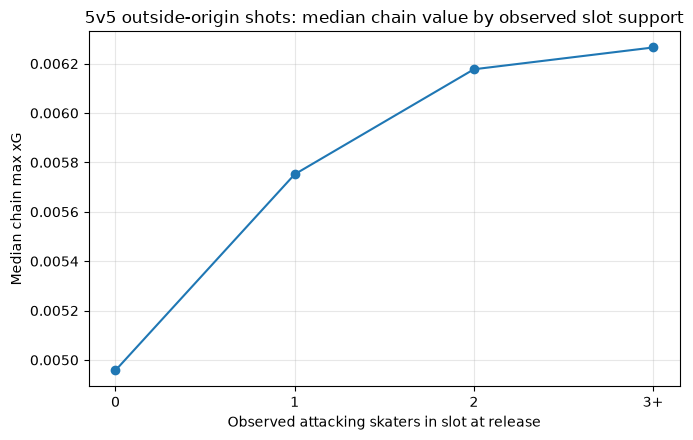

In [25]:
# Plot median chain value by observed attacking slot support

plt.figure(figsize=(7, 4.5))
plt.plot(
    plot_summary["observed_attackers_slot_bin"],
    plot_summary["median_chain_max_xg"],
    marker="o",
)

plt.xlabel("Observed attacking skaters in slot at release")
plt.ylabel("Median chain max xG")
plt.title("5v5 outside-origin shots: median chain value by observed slot support")
plt.grid(True, alpha=0.3)
plt.tight_layout()

fig_path = FIGURES_DIR / "5v5_outside_median_chain_value_by_observed_slot_support.png"
if SAVE_DIAGNOSTIC_FIGURES:
    FIGURES_DIR.mkdir(exist_ok=True)
    plt.savefig(fig_path, dpi=200)
else:
    fig_path = None

plt.show()

fig_path

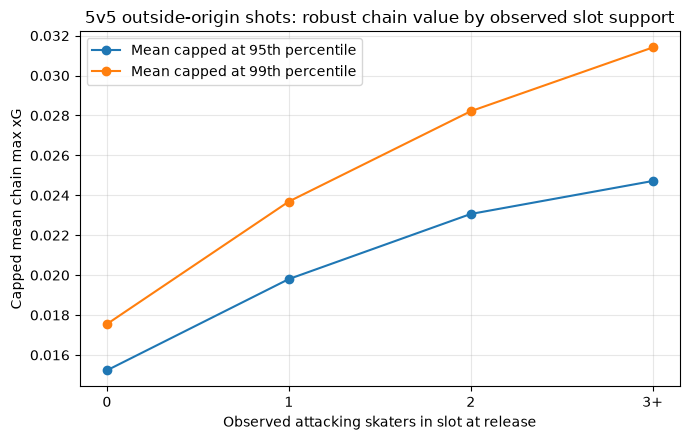

In [26]:
# Plot capped mean chain value by observed attacking slot support

plt.figure(figsize=(7, 4.5))
plt.plot(
    robust_summary_by_support["observed_attackers_slot_bin"].astype(str),
    robust_summary_by_support["mean_chain_max_xg_capped_95"],
    marker="o",
    label="Mean capped at 95th percentile",
)
plt.plot(
    robust_summary_by_support["observed_attackers_slot_bin"].astype(str),
    robust_summary_by_support["mean_chain_max_xg_capped_99"],
    marker="o",
    label="Mean capped at 99th percentile",
)

plt.xlabel("Observed attacking skaters in slot at release")
plt.ylabel("Capped mean chain max xG")
plt.title("5v5 outside-origin shots: robust chain value by observed slot support")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

fig_path = FIGURES_DIR / "5v5_outside_capped_mean_chain_value_by_observed_slot_support.png"
if SAVE_DIAGNOSTIC_FIGURES:
    FIGURES_DIR.mkdir(exist_ok=True)
    plt.savefig(fig_path, dpi=200)
else:
    fig_path = None

plt.show()

fig_path

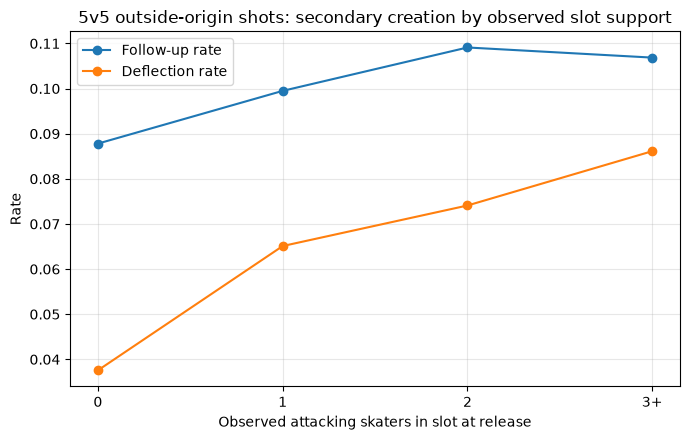

In [27]:
# Plot follow-up and deflection rates by observed attacking slot support

plt.figure(figsize=(7, 4.5))
plt.plot(
    plot_summary["observed_attackers_slot_bin"],
    plot_summary["followup_rate"],
    marker="o",
    label="Follow-up rate",
)
plt.plot(
    plot_summary["observed_attackers_slot_bin"],
    plot_summary["deflection_rate"],
    marker="o",
    label="Deflection rate",
)

plt.xlabel("Observed attacking skaters in slot at release")
plt.ylabel("Rate")
plt.title("5v5 outside-origin shots: secondary creation by observed slot support")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

fig_path = FIGURES_DIR / "5v5_outside_secondary_creation_by_observed_slot_support.png"
if SAVE_DIAGNOSTIC_FIGURES:
    FIGURES_DIR.mkdir(exist_ok=True)
    plt.savefig(fig_path, dpi=200)
else:
    fig_path = None

plt.show()

fig_path

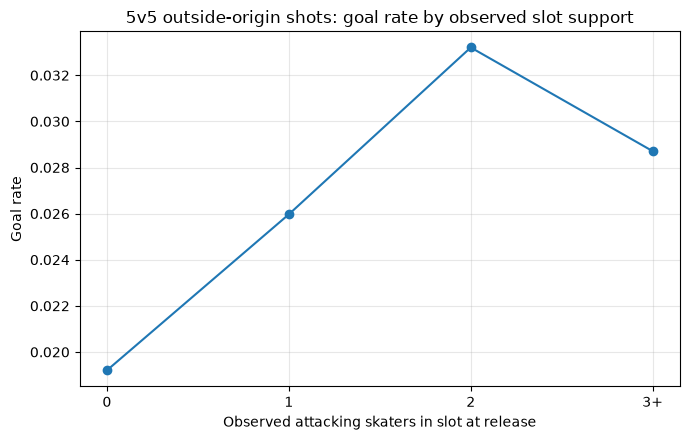

In [28]:
# Plot goal rate by observed attacking slot support

plt.figure(figsize=(7, 4.5))
plt.plot(
    plot_summary["observed_attackers_slot_bin"],
    plot_summary["goal_rate"],
    marker="o",
)

plt.xlabel("Observed attacking skaters in slot at release")
plt.ylabel("Goal rate")
plt.title("5v5 outside-origin shots: goal rate by observed slot support")
plt.grid(True, alpha=0.3)
plt.tight_layout()

fig_path = FIGURES_DIR / "5v5_outside_goal_rate_by_observed_slot_support.png"
if SAVE_DIAGNOSTIC_FIGURES:
    FIGURES_DIR.mkdir(exist_ok=True)
    plt.savefig(fig_path, dpi=200)
else:
    fig_path = None

plt.show()

fig_path

## 11. Preliminary Analysis Summary Table

This table keeps the key denominators and outcome metrics together.

The table should be interpreted as preliminary because rush, in-zone, and faceoff contexts have not yet been separated.

In [29]:
# Create a compact analysis summary table for review

analysis_summary_table = summary_by_attack_support[
    [
        "observed_attackers_slot_bin",
        "chains",
        "median_chain_max_xg",
        "mean_chain_max_xg",
        "p75_chain_max_xg",
        "p90_chain_max_xg",
        "followup_rate",
        "deflection_rate",
        "goal_rate",
        "mean_observed_defenders_in_slot",
        "mean_attacker_skaters_tracked",
        "mean_defender_skaters_tracked",
    ]
].copy()

analysis_summary_table

,observed_attackers_slot_bin,chains,median_chain_max_xg,mean_chain_max_xg,p75_chain_max_xg,p90_chain_max_xg,followup_rate,deflection_rate,goal_rate,mean_observed_defenders_in_slot,mean_attacker_skaters_tracked,mean_defender_skaters_tracked
0,0,8280,0.004958,0.018228,0.013312,0.039763,0.087802,0.037560,0.019203,1.305676,2.120652,3.228865
1,1,8202,0.005752,0.025088,0.017855,0.069089,0.099488,0.065106,0.025969,2.014996,2.998171,3.463545
2,2,4427,0.006177,0.030378,0.024606,0.086784,0.109103,0.074091,0.033205,2.346284,3.774565,3.587757
3,3+,627,0.006265,0.032636,0.024721,0.102332,0.106858,0.086124,0.028708,2.620415,4.371611,3.594896


In [30]:
# Format the analysis summary table for easier notebook review

analysis_summary_table_formatted = analysis_summary_table.copy()

rate_columns = [
    "followup_rate",
    "deflection_rate",
    "goal_rate",
]

xg_columns = [
    "median_chain_max_xg",
    "mean_chain_max_xg",
    "p75_chain_max_xg",
    "p90_chain_max_xg",
]

count_like_columns = [
    "mean_observed_defenders_in_slot",
    "mean_attacker_skaters_tracked",
    "mean_defender_skaters_tracked",
]

for col in rate_columns:
    analysis_summary_table_formatted[col] = (
        100 * analysis_summary_table_formatted[col]
    ).round(2)

for col in xg_columns:
    analysis_summary_table_formatted[col] = analysis_summary_table_formatted[col].round(4)

for col in count_like_columns:
    analysis_summary_table_formatted[col] = analysis_summary_table_formatted[col].round(2)

analysis_summary_table_formatted[
    [
        "observed_attackers_slot_bin",
        "chains",
        "median_chain_max_xg",
        "mean_chain_max_xg",
        "p75_chain_max_xg",
        "p90_chain_max_xg",
        "followup_rate",
        "deflection_rate",
        "goal_rate",
        "mean_observed_defenders_in_slot",
        "mean_attacker_skaters_tracked",
        "mean_defender_skaters_tracked",
    ]
]

,observed_attackers_slot_bin,chains,median_chain_max_xg,mean_chain_max_xg,p75_chain_max_xg,p90_chain_max_xg,followup_rate,deflection_rate,goal_rate,mean_observed_defenders_in_slot,mean_attacker_skaters_tracked,mean_defender_skaters_tracked
0,0,8280,0.005000,0.018200,0.013300,0.039800,8.780000,3.760000,1.920000,1.310000,2.120000,3.230000
1,1,8202,0.005800,0.025100,0.017900,0.069100,9.950000,6.510000,2.600000,2.010000,3.000000,3.460000
2,2,4427,0.006200,0.030400,0.024600,0.086800,10.910000,7.410000,3.320000,2.350000,3.770000,3.590000
3,3+,627,0.006300,0.032600,0.024700,0.102300,10.690000,8.610000,2.870000,2.620000,4.370000,3.590000


In [31]:
# Rename formatted columns for readable display without changing the underlying source table

analysis_summary_table_display = analysis_summary_table_formatted.rename(
    columns={
        "observed_attackers_slot_bin": "observed_attackers_in_slot",
        "chains": "chains",
        "median_chain_max_xg": "median_chain_max_xg",
        "mean_chain_max_xg": "mean_chain_max_xg",
        "p75_chain_max_xg": "p75_chain_max_xg",
        "p90_chain_max_xg": "p90_chain_max_xg",
        "followup_rate": "followup_rate_pct",
        "deflection_rate": "deflection_rate_pct",
        "goal_rate": "goal_rate_pct",
        "mean_observed_defenders_in_slot": "mean_observed_defenders_in_slot",
        "mean_attacker_skaters_tracked": "mean_attacker_skaters_tracked",
        "mean_defender_skaters_tracked": "mean_defender_skaters_tracked",
    }
)

analysis_summary_table_display

,observed_attackers_in_slot,chains,median_chain_max_xg,mean_chain_max_xg,p75_chain_max_xg,p90_chain_max_xg,followup_rate_pct,deflection_rate_pct,goal_rate_pct,mean_observed_defenders_in_slot,mean_attacker_skaters_tracked,mean_defender_skaters_tracked
0,0,8280,0.005000,0.018200,0.013300,0.039800,8.780000,3.760000,1.920000,1.310000,2.120000,3.230000
1,1,8202,0.005800,0.025100,0.017900,0.069100,9.950000,6.510000,2.600000,2.010000,3.000000,3.460000
2,2,4427,0.006200,0.030400,0.024600,0.086800,10.910000,7.410000,3.320000,2.350000,3.770000,3.590000
3,3+,627,0.006300,0.032600,0.024700,0.102300,10.690000,8.610000,2.870000,2.620000,4.370000,3.590000


## 12. Computed Diagnostic Notes

This section prints data-derived diagnostics from the current analysis cohort.

These notes are not final interpretation language. They are checks to help decide what claims are supported by the current output.

In [32]:
# Compute diagnostic comparisons from the current observed attacking slot-support summary

diagnostic = summary_by_attack_support.copy()
diagnostic["slot_bin_str"] = diagnostic["observed_attackers_slot_bin"].astype(str)

baseline = diagnostic.loc[diagnostic["slot_bin_str"].eq("0")].iloc[0]
one_support = diagnostic.loc[diagnostic["slot_bin_str"].eq("1")].iloc[0]
two_support = diagnostic.loc[diagnostic["slot_bin_str"].eq("2")].iloc[0]
three_plus_support = diagnostic.loc[diagnostic["slot_bin_str"].eq("3+")].iloc[0]

metric_names = [
    "median_chain_max_xg",
    "mean_chain_max_xg",
    "followup_rate",
    "deflection_rate",
    "goal_rate",
]

marginal_rows = []
for metric in metric_names:
    marginal_rows.extend(
        [
            {
                "metric": metric,
                "comparison": "0_to_1",
                "start_value": baseline[metric],
                "end_value": one_support[metric],
                "absolute_change": one_support[metric] - baseline[metric],
                "relative_change_pct": np.nan if baseline[metric] == 0 else 100 * (one_support[metric] / baseline[metric] - 1),
            },
            {
                "metric": metric,
                "comparison": "1_to_2",
                "start_value": one_support[metric],
                "end_value": two_support[metric],
                "absolute_change": two_support[metric] - one_support[metric],
                "relative_change_pct": np.nan if one_support[metric] == 0 else 100 * (two_support[metric] / one_support[metric] - 1),
            },
            {
                "metric": metric,
                "comparison": "2_to_3_plus",
                "start_value": two_support[metric],
                "end_value": three_plus_support[metric],
                "absolute_change": three_plus_support[metric] - two_support[metric],
                "relative_change_pct": np.nan if two_support[metric] == 0 else 100 * (three_plus_support[metric] / two_support[metric] - 1),
            },
        ]
    )

marginal_diagnostics = pd.DataFrame(marginal_rows)

computed_diagnostics = {
    "analysis_chains": len(analysis),
    "offensive_blue_line_x_adj": OFFENSIVE_BLUE_LINE_X_ADJ,
    "slot_bin_counts": analysis["observed_attackers_slot_bin"].value_counts(dropna=False).sort_index().to_dict(),
    "tracking_bucket_counts": tracking_bucket_counts.set_index(
        "origin_tracking_completeness_bucket"
    )["chains"].to_dict(),
    "goal_rate_2_minus_3_plus": two_support["goal_rate"] - three_plus_support["goal_rate"],
    "median_chain_value_1_to_2_minus_0_to_1": (
        (two_support["median_chain_max_xg"] - one_support["median_chain_max_xg"])
        - (one_support["median_chain_max_xg"] - baseline["median_chain_max_xg"])
    ),
}

computed_diagnostics


{'analysis_chains': 21536,
 'offensive_blue_line_x_adj': 25,
 'slot_bin_counts': {'0': 8280, '1': 8202, '2': 4427, '3+': 627},
 'tracking_bucket_counts': {'partial_observed': 17657,
  'high_observed': 3392,
  'near_full_observed': 487},
 'goal_rate_2_minus_3_plus': np.float64(0.00449719695258435),
 'median_chain_value_1_to_2_minus_0_to_1': np.float64(-0.00036875903606414795)}

In [33]:
# Display marginal changes between adjacent observed slot-support bins

marginal_diagnostics


,metric,comparison,start_value,end_value,absolute_change,relative_change_pct
0,median_chain_max_xg,0_to_1,0.004958,0.005752,0.000794,16.013241
1,median_chain_max_xg,1_to_2,0.005752,0.006177,0.000425,7.391867
2,median_chain_max_xg,2_to_3_plus,0.006177,0.006265,0.000088,1.429140
3,mean_chain_max_xg,0_to_1,0.018228,0.025088,0.006861,37.638952
4,mean_chain_max_xg,1_to_2,0.025088,0.030378,0.005289,21.083315
5,mean_chain_max_xg,2_to_3_plus,0.030378,0.032636,0.002258,7.434025
6,followup_rate,0_to_1,0.087802,0.099488,0.011686,13.309499
7,followup_rate,1_to_2,0.099488,0.109103,0.009615,9.664791
8,followup_rate,2_to_3_plus,0.109103,0.106858,-0.002245,-2.057846
9,deflection_rate,0_to_1,0.037560,0.065106,0.027546,73.337065


In [34]:
# Convert the diagnostics into cautious claim checks focused on marginal effects and plateaus

claim_checks = pd.DataFrame(
    [
        {
            "claim_check": "largest_median_chain_value_jump_is_0_to_1",
            "supported": (
                marginal_diagnostics.query("metric == 'median_chain_max_xg' and comparison == '0_to_1'")["absolute_change"].iloc[0]
                > marginal_diagnostics.query("metric == 'median_chain_max_xg' and comparison == '1_to_2'")["absolute_change"].iloc[0]
            ),
            "diagnostic_note": "Tests whether the first slot layer matters more than adding a second.",
        },
        {
            "claim_check": "largest_median_chain_value_jump_is_1_to_2",
            "supported": (
                marginal_diagnostics.query("metric == 'median_chain_max_xg' and comparison == '1_to_2'")["absolute_change"].iloc[0]
                > marginal_diagnostics.query("metric == 'median_chain_max_xg' and comparison == '0_to_1'")["absolute_change"].iloc[0]
            ),
            "diagnostic_note": "Tests whether the second slot layer is the more interesting threshold.",
        },
        {
            "claim_check": "goal_rate_drops_from_2_to_3_plus",
            "supported": three_plus_support["goal_rate"] < two_support["goal_rate"],
            "diagnostic_note": "Potentially interesting only if it survives context filters and sample-size checks.",
        },
        {
            "claim_check": "followup_rate_plateaus_or_drops_from_2_to_3_plus",
            "supported": three_plus_support["followup_rate"] <= two_support["followup_rate"],
            "diagnostic_note": "Tests whether more than two observed attackers stops adding secondary creation value.",
        },
        {
            "claim_check": "deflection_rate_continues_to_rise_from_2_to_3_plus",
            "supported": three_plus_support["deflection_rate"] > two_support["deflection_rate"],
            "diagnostic_note": "Separates screen/tip traffic from rebound/follow-up creation.",
        },
        {
            "claim_check": "3_plus_bin_has_at_least_500_chains",
            "supported": int(three_plus_support["chains"]) >= 500,
            "diagnostic_note": "Minimum practical sample-size check for treating the 3+ pattern as more than noise.",
        },
    ]
)

claim_checks


,claim_check,supported,diagnostic_note
0,largest_median_chain_value_jump_is_0_to_1,True,Tests whether the first slot layer matters mor...
1,largest_median_chain_value_jump_is_1_to_2,False,Tests whether the second slot layer is the mor...
2,goal_rate_drops_from_2_to_3_plus,True,Potentially interesting only if it survives co...
3,followup_rate_plateaus_or_drops_from_2_to_3_plus,True,Tests whether more than two observed attackers...
4,deflection_rate_continues_to_rise_from_2_to_3_...,True,Separates screen/tip traffic from rebound/foll...
5,3_plus_bin_has_at_least_500_chains,True,Minimum practical sample-size check for treati...


## 13. Optional Export Of Diagnostic Artifacts

This section is disabled by default.

The notebook should be committed as the reproducible source of truth. Diagnostic PNG and CSV artifacts should only be exported when specifically needed for review.


In [35]:
# Optionally save diagnostic tables and figures for local review

if EXPORT_REVIEW_ARTIFACTS:
    import json

    TABLES_DIR = PROJECT_ROOT / "reports" / "tables" / "07_preliminary_5v5_outside_slot_support"
    TABLES_DIR.mkdir(parents=True, exist_ok=True)

    tables_to_save = {
        "cohort_waterfall.csv": cohort_waterfall,
        "slot_bin_counts.csv": slot_bin_counts.rename_axis("observed_attackers_slot_bin").reset_index(name="chains"),
        "summary_by_attack_support.csv": summary_by_attack_support,
        "marginal_diagnostics.csv": marginal_diagnostics,
        "robust_summary_by_support.csv": robust_summary_by_support,
        "tracking_bucket_counts.csv": tracking_bucket_counts,
        "summary_by_tracking_bucket.csv": summary_by_tracking_bucket,
        "summary_by_tracking_bucket_display.csv": summary_by_tracking_bucket_display,
        "summary_by_attack_and_defense.csv": summary_by_attack_and_defense,
        "summary_by_attack_and_defense_display.csv": summary_by_attack_and_defense_display,
        "value_distribution_by_support.csv": value_distribution_by_support,
        "analysis_summary_table.csv": analysis_summary_table,
        "analysis_summary_table_display.csv": analysis_summary_table_display,
        "claim_checks.csv": claim_checks,
    }

    saved_table_paths = []

    for filename, table in tables_to_save.items():
        output_path = TABLES_DIR / filename
        table_to_write = table.copy()

        for col in table_to_write.columns:
            if isinstance(table_to_write[col].dtype, pd.CategoricalDtype):
                table_to_write[col] = table_to_write[col].astype(str)

        table_to_write.to_csv(output_path, index=False)
        saved_table_paths.append(output_path)

    diagnostics_output_path = TABLES_DIR / "computed_diagnostics.json"

    json_ready_diagnostics = {}
    for key, value in computed_diagnostics.items():
        if isinstance(value, dict):
            json_ready_diagnostics[key] = {
                str(k): int(v) if isinstance(v, (np.integer, int)) else float(v) if isinstance(v, (np.floating, float)) else v
                for k, v in value.items()
            }
        elif isinstance(value, (np.integer, int)):
            json_ready_diagnostics[key] = int(value)
        elif isinstance(value, (np.floating, float)):
            json_ready_diagnostics[key] = float(value)
        else:
            json_ready_diagnostics[key] = value

    with open(diagnostics_output_path, "w", encoding="utf-8") as f:
        json.dump(json_ready_diagnostics, f, indent=2)

    export_manifest = pd.DataFrame(
        [
            {
                "export_type": "table",
                "filename": path.name,
                "exists": path.exists(),
                "size_bytes": path.stat().st_size if path.exists() else 0,
            }
            for path in saved_table_paths + [diagnostics_output_path]
        ]
    )
else:
    export_manifest = pd.DataFrame(
        columns=["export_type", "filename", "exists", "size_bytes"]
    )

export_manifest


,export_type,filename,exists,size_bytes


## 14. Final Notebook Validation

Run lightweight checks before committing the notebook.

This validates the analysis cohort, blue-line exclusion, summary tables, marginal diagnostics, and optional export state.


In [36]:
# Validate the final state of the preliminary analysis notebook

final_notebook_validation = {
    "input_rows": len(df),
    "analysis_rows": len(analysis),
    "analysis_unique_chain_ids": analysis["chain_id"].nunique(),
    "analysis_duplicate_chain_ids": analysis.duplicated("chain_id").sum(),
    "behind_blue_line_rows_in_analysis": int((analysis["anchor_origin_x_adj"] < OFFENSIVE_BLUE_LINE_X_ADJ).sum()),
    "slot_bins": analysis["observed_attackers_slot_bin"].value_counts(dropna=False).sort_index().to_dict(),
    "summary_rows": len(summary_by_attack_support),
    "marginal_diagnostic_rows": len(marginal_diagnostics),
    "claim_check_rows": len(claim_checks),
    "export_review_artifacts": EXPORT_REVIEW_ARTIFACTS,
    "export_manifest_rows": len(export_manifest),
}

assert final_notebook_validation["analysis_duplicate_chain_ids"] == 0
assert final_notebook_validation["behind_blue_line_rows_in_analysis"] == 0
assert final_notebook_validation["summary_rows"] == 4
assert final_notebook_validation["marginal_diagnostic_rows"] == 15
assert final_notebook_validation["claim_check_rows"] == 6

final_notebook_validation


{'input_rows': 48673,
 'analysis_rows': 21536,
 'analysis_unique_chain_ids': 21536,
 'analysis_duplicate_chain_ids': np.int64(0),
 'behind_blue_line_rows_in_analysis': 0,
 'slot_bins': {'0': 8280, '1': 8202, '2': 4427, '3+': 627},
 'summary_rows': 4,
 'marginal_diagnostic_rows': 15,
 'claim_check_rows': 6,
 'export_review_artifacts': False,
 'export_manifest_rows': 0}